Decision Tree,SVM and Random Forest for both classification and regression.

We have explored algorithms that are either Linear(Logistic regression) or probablistic(Naive Bayes).Today we are checking three new families:
- Support Vector Machine(SVR,SVC)---> margin based
- Decision Tree(DT fror regression and classification)---> rules based
- Random Forest(RF for regression and classification)---> collection of DT

# Support Vector Machine(SVM)

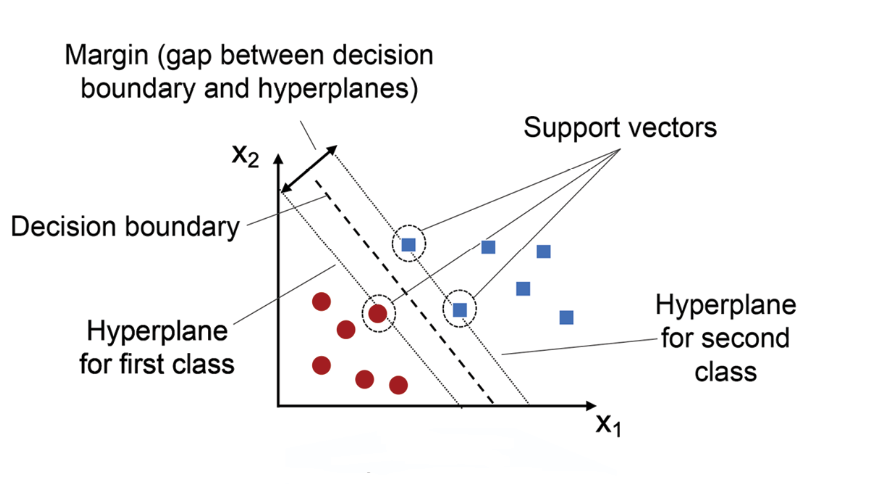

- SVM tries to find the best possible boundary between classes
- Margin wont be that clear to differentiate between points.(that we want)
- hence for blue and red separately hyper planes
- best decision boundary-boundary that maximizes the margin between the classes
- margin= distance between the boundary and the closest data points or distance between two hyperplanes
- svm finds the best decision boundary

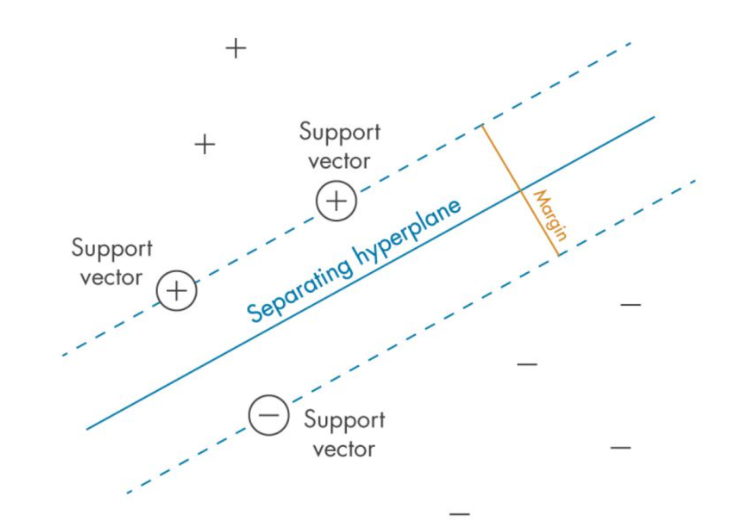

### What is support vector?

- critical points that lie on the margin

## Pros:
- very strong performance for medium sized dataset(around 2000 points)
- excellent for high dimensional data
- Robust to outliers

## Cons:
- slow on large dataset
- if encoding is there can do
- requires scaling(compulsory)
- choosing the right hyperparameters is tricky

# Decision Tree Algorithm

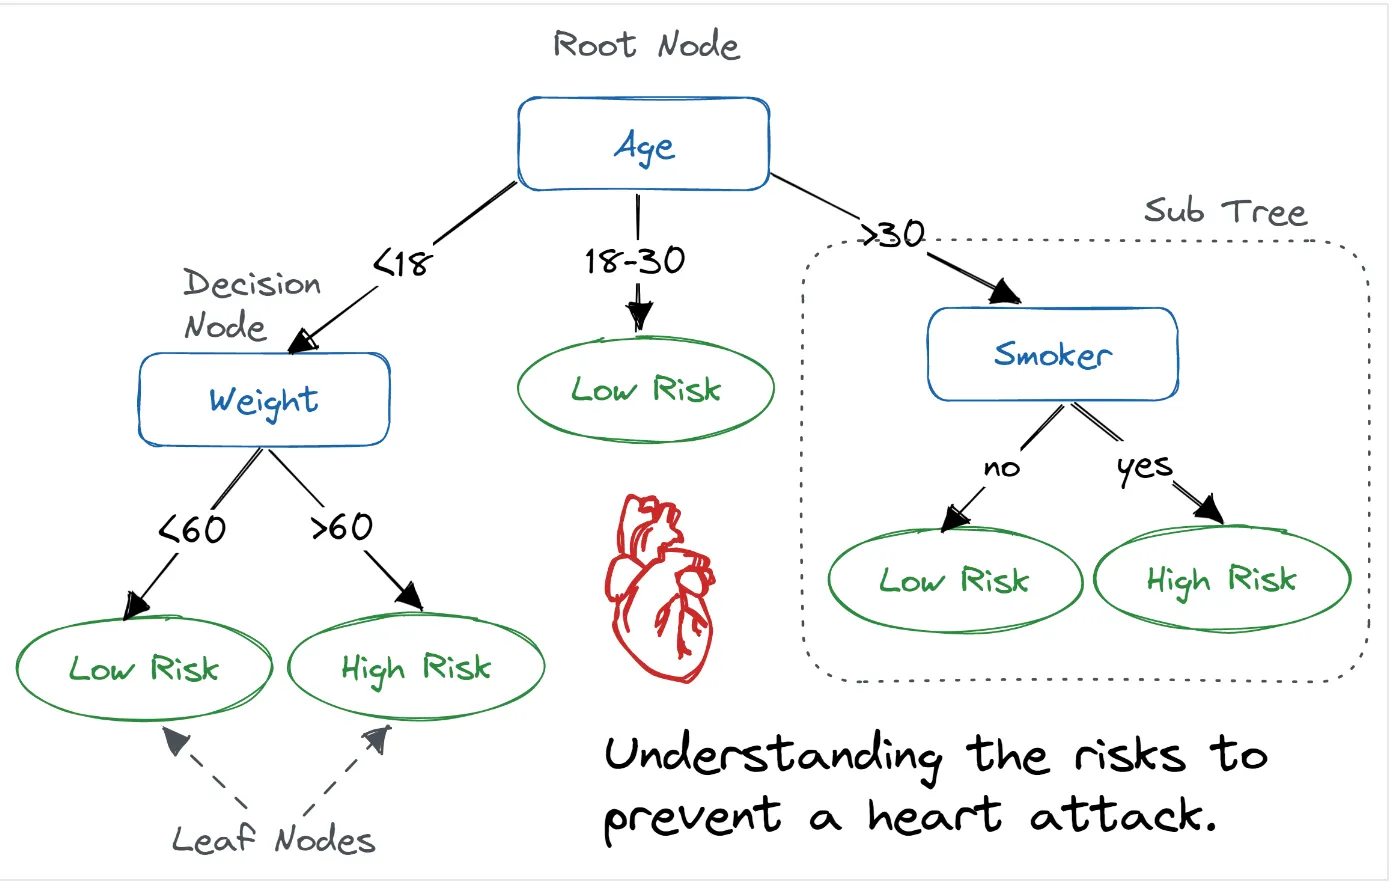

## Why?
- Decision tree splits the dataset into regions using if-else rule for different features
- Splits occur based on information gain or Gini impurity
- Each path from root to leaf is a decision rule
- keep splitting until no more
- rule which we start is root node
- and when u reach a place where no more splitting condition is leaf node-last node where no more splitting
- very easy to interpret and hence more preferred
- works with data that has both numerical and categorical features,categorical best
- no need scaling as each time only 1 feature we r taking + handle non linearity


In [ ]:
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor

# Random Forest

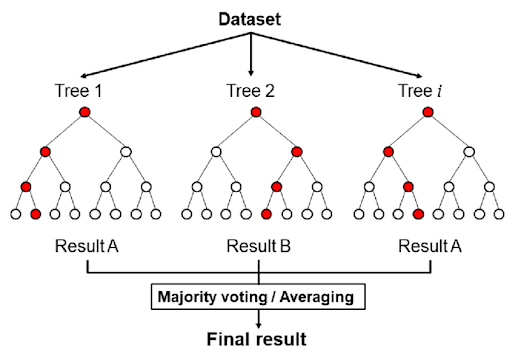

- A decision tree is unstable and can overfit
- Random Forest(which is a collection of decision trees), builds many trees and combines their output(bagging).
- Each tree sees:
    - subset of the data
    - random subset of features
    - each tree-->weak lerner,combined-->strong learner more complete picture

In [ ]:
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor

# Project: Regression

## Step 0: choose the dataset

California dataset of housing prices

In [ ]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data= fetch_california_housing(as_frame=True)
df=data.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Step 1: Problem statement

Predict the median house value in each district of California based on provided features

In [ ]:
# Target: Median house value

## Step 2: understanding data

In [ ]:
df.shape

(20640, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [ ]:
df.isna().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


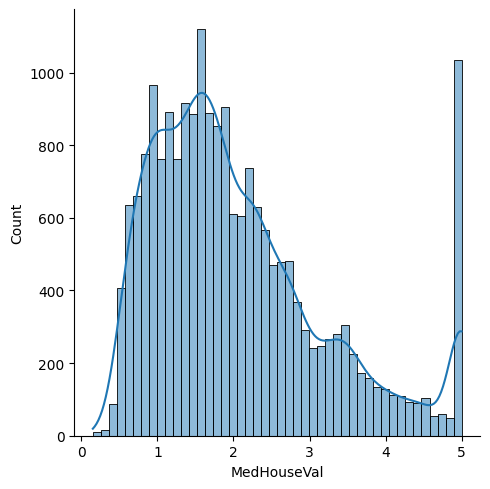

In [ ]:
# what distribution my target column is following
sns.displot(df['MedHouseVal'],kde=True) #slightly skewed to right #kde displays line

## Step 3: Preprocessing

In [ ]:
# split the features and target
x= df.drop('MedHouseVal',axis=1)
y=df['MedHouseVal'] #target

In [ ]:
#scale features--> stdScaler
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [ ]:
# do we need to log transform?
# for regression yes,as it improves the answer for svm for other 2 no need
import numpy as np
#y=np.log(y)
#y

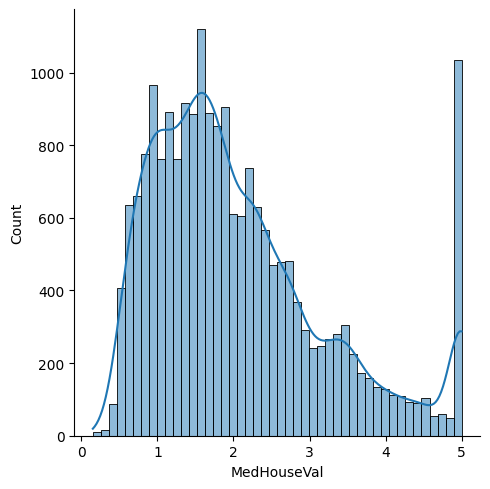

In [ ]:
# check distribution of y # not much difference here
sns.displot(y,kde=True)

## Step 4: Model Training

In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.2,random_state=42)

### 4A: SVM Regressor

In [ ]:
from sklearn.svm import SVR

svr= SVR(kernel='rbf')
svr.fit(x_train,y_train)

SVR()

### 4B: Decision Tree Regressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor

dtr=DecisionTreeRegressor()
dtr.fit(x_train,y_train)

DecisionTreeRegressor()

### 4C: Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rfr=RandomForestRegressor()
rfr.fit(x_train,y_train)

RandomForestRegressor()

## Step 5: Predictions

In [ ]:
# predictions through all 3 models
y_pred_svr=svr.predict(x_test)
y_pred_dtr=dtr.predict(x_test)
y_pred_rfr=rfr.predict(x_test)

## Step 6: Evaluation

In [ ]:
# actual result--> y_test

# regression metrics: RMSE,R2 score

from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

mse_svr=mean_squared_error(y_test,y_pred_svr)
mse_dtr=mean_squared_error(y_test,y_pred_dtr)
mse_rfr=mean_squared_error(y_test,y_pred_rfr)

mae_svr=mean_absolute_error(y_test,y_pred_svr)
mae_dtr=mean_absolute_error(y_test,y_pred_dtr)
mae_rfr=mean_absolute_error(y_test,y_pred_rfr)

r2_svr= r2_score(y_test,y_pred_svr)
r2_dtr= r2_score(y_test,y_pred_dtr)
r2_rfr= r2_score(y_test,y_pred_rfr)

results_df=pd.DataFrame({
    'Model':['SVR','Decision Tree','Random Forest'],
    'MSE':[mse_svr,mse_dtr,mse_rfr],
    'MAE':[mae_svr,mae_dtr,mae_rfr],
    'R2 Score':[r2_svr,r2_dtr,r2_rfr]
})

results_df

,Model,MSE,MAE,R2 Score
0,SVR,0.355198,0.397763,0.728941
1,Decision Tree,0.503859,0.455839,0.615495
2,Random Forest,0.251927,0.325745,0.807750


## Step 7: Conclusion and inferences

- Random Forest Regressor gives the best r2 score and the lowest error
- you can conclude that Random Forest, which is a collection of multiple algorithms is powerful that single stand alone algorithms like SVR or DT

## What is feature importance in Random Forest?

- Random Forest is an ensemble of decision trees.Each tree splits the features to reduce the prediction error(to reduce MSE)

- Feature importance--> how much does a feature contribute to reducing the error across all trees,on average

- Every time a features is used to split a node, the model measures how much MSE decreased because of this feature introduction and its splitting like this for each tree

- It adds up these decreases over all trees for each feature and then normalises it so all feature importance sums to 1

- high importance---> feature is really useful for splitting the data and reducing the error so that feature we have to keep

- low importance--> feature dosent help much

In [ ]:
# i have already trained a rfr
importances=rfr.feature_importances_ # a speciality of rfr it can give the important features as it checks like above no need pca from this we can decide
feature_names=x.columns

fi_df=pd.DataFrame({
    'Feature':feature_names,
    'Importance': importances
}).sort_values(by='Importance',ascending=False)

fi_df

,Feature,Importance
0,MedInc,0.523662
5,AveOccup,0.138265
6,Latitude,0.090354
7,Longitude,0.089901
1,HouseAge,0.054222
2,AveRooms,0.043631
4,Population,0.031126
3,AveBedrms,0.028839


Random Forest has learned that median income find our target itself explained most of the variation in house value,followed by Average Room occupation

## Step 8: Hyperparameter Tuning for Random Forest(regression)

- to find which version after optimizing of random forest using few hyperparameters
- Hyper parameters control the model complexity,bias-variance tradeoff before training
- Choose GridSearchCV or RandomizedSearchCV

In [ ]:
# select hyperparameters from documentaion
from sklearn.model_selection import RandomizedSearchCV

# assigning
rf_base=RandomForestRegressor(random_state=42,n_jobs=1) #The number of jobs to run in parallel. # set a base
# now for many
param_dist={
    'n_estimators':[100,200,300,400],
    'max_depth':[None,10,20,30],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4],
    'max_features':['auto','sort',0.8] #0.8=80% of features
}

In [ ]:
# we need to optimze negative MSE
# assigning search for which model what to find etc
rf_search=RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=10, # try 10 random combos
    cv=5, # cross validation=5
    scoring='neg_mean_squared_error',
    verbose=2,
    n_jobs=1,
    random_state=42
)

In [ ]:
# run the search for our data
# now
rf_search.fit(x_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END max_depth=30, max_features=0.8, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=  10.2s
[CV] END max_depth=30, max_features=0.8, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=   9.8s
[CV] END max_depth=30, max_features=0.8, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=   9.8s
[CV] END max_depth=30, max_features=0.8, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=  10.6s
[CV] END max_depth=30, max_features=0.8, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=  10.3s
[CV] END max_depth=None, max_features=0.8, min_samples_leaf=1, min_samples_split=2, n_estimators=400; total time=  54.1s
[CV] END max_depth=None, max_features=0.8, min_samples_leaf=1, min_samples_split=2, n_estimators=400; total time=  59.3s
[CV] END max_depth=None, max_features=0.8, min_samples_leaf=1, min_samples_split=2, n_estimators=400; 

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
25 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_p

RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(n_jobs=1, random_state=42),
                   n_jobs=1,
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'max_features': ['auto', 'sort', 0.8],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 400]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

In [ ]:
# inspect the best hyperparameter found
# the best parameters
print("Best parameters:",rf_search.best_params_)
print("Best CV score (neg MSE):", rf_search.best_score_)

Best parameters: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.8, 'max_depth': None}
Best CV score (neg MSE): -0.25463531495345726


In [ ]:
# evalaute the best model on the test set
# doing for our new rfr
best_rf = rf_search.best_estimator_ # new learnt after search and in that trained so with that predict
y_pred_best_rf = best_rf.predict(x_test)

mse_best_rf = mean_squared_error(y_test,y_pred_best_rf)
r2_best_rf = r2_score(y_test,y_pred_best_rf)
mae_best_rf = mean_absolute_error(y_test,y_pred_best_rf)


results_df = pd.DataFrame({
    'Model': ['SVR', 'Decision Tree', 'Random Forest', 'Best Random Forest'],
    'MSE': [mse_svr,mse_dtr,mse_rfr,mse_best_rf],
    'MAE':[mae_svr,mae_dtr,mae_rfr,mae_best_rf],
    'R2 Score': [r2_svr,r2_dtr,r2_rfr,r2_best_rf]
})

results_df

,Model,MSE,MAE,R2 Score
0,SVR,0.355198,0.397763,0.728941
1,Decision Tree,0.503859,0.455839,0.615495
2,Random Forest,0.251927,0.325745,0.807750
3,Best Random Forest,0.250512,0.324121,0.808829


In [ ]:
# slight increase